Descarga y Localización Real

In [13]:
import kagglehub
import os
from pathlib import Path

# 1. Descarga del dataset
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
DATASET_PATH = Path(path)

# 2. Localizar la carpeta que contiene las clases
# El dataset suele tener esta estructura: .../The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/
# Buscamos la carpeta que tenga dentro "Normal cases"
def find_image_folder(base_path):
    for root, dirs, files in os.walk(base_path):
        if "Normal cases" in dirs and "Malignant cases" in dirs:
            return root
    return None

IMAGE_SOURCE_PATH = find_image_folder(DATASET_PATH)

if IMAGE_SOURCE_PATH:
    print(f" Carpeta de imágenes localizada en: {IMAGE_SOURCE_PATH}")
    print("Contenido:", os.listdir(IMAGE_SOURCE_PATH))
else:
    print(" No se encontró la carpeta con las clases. Revisa la descarga.")

Using Colab cache for faster access to the 'iqothnccd-lung-cancer-dataset' dataset.
 Carpeta de imágenes localizada en: /kaggle/input/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset
Contenido: ['IQ-OTH_NCCD lung cancer dataset.txt', 'Normal cases', 'Bengin cases', 'Malignant cases']


División de Datos (Split-Folders)

In [14]:
!pip install split-folders -q
import splitfolders

OUTPUT_DIR = "/content/dataset_dividido"

# Dividimos el dataset original en la nueva estructura
splitfolders.ratio(IMAGE_SOURCE_PATH, output=OUTPUT_DIR, seed=42, ratio=(0.8, 0.1, 0.1))

print("\n División completada.")
print("Verificación de clases en Train:", os.listdir(os.path.join(OUTPUT_DIR, 'train')))

Copying files: 1097 files [00:05, 206.84 files/s]


 División completada.
Verificación de clases en Train: ['figure', 'Bengin cases', 'Malignant cases', 'Normal cases']


Generadores de Datos (Data Augmentation)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 878 images belonging to 4 classes.
Found 109 images belonging to 4 classes.
Found 113 images belonging to 4 classes.


### Justificación Técnica: Implementación de *Data Augmentation*

Durante la fase de preparación de datos para el entrenamiento de la red neuronal, se ha aplicado la técnica de **Data Augmentation** (Aumentación de Datos) exclusivamente al conjunto de entrenamiento (aprox. 878 imágenes). Esta decisión metodológica se fundamenta en tres pilares críticos para el éxito del modelo predictivo:

#### 1. Mitigación del Desbalanceo Severo de Clases
Como se evidenció en el Análisis Exploratorio de Datos (EDA), el dataset presenta un desbalanceo extremo, con la clase `Benign cases` representando menos del 10% del total frente a la clase mayoritaria `Malignant cases`. Si bien se han aplicado *Class Weights* para penalizar matemáticamente los errores en la clase minoritaria, el *Data Augmentation* actúa de forma sinérgica generando dinámicamente variaciones visuales de estas escasas muestras. Esto evita que el modelo memorice las 102 imágenes benignas exactas y aprenda patrones generales.

#### 2. Prevención del Sobreajuste (*Overfitting*)
Las Redes Neuronales Convolucionales (CNN) son arquitecturas con miles o millones de parámetros que tienden a sobreajustarse rápidamente cuando se entrenan con datasets pequeños (menos de 1000 imágenes). Al aplicar transformaciones aleatorias *al vuelo* en cada *epoch* (tales como `rotation_range`, `width_shift`, `zoom_range` y `horizontal_flip`), forzamos a la red a no depender de la ubicación exacta del píxel o la orientación del pulmón, obligándola a abstraer características radiómicas invariantes (texturas, bordes espiculados y densidades del nódulo).

#### 3. Simulación de Variabilidad Clínica Real
Las transformaciones geométricas aplicadas no son arbitrarias; simulan condiciones reales en la adquisición de Tomografías Computarizadas (TC).
* **Rotación y desplazamientos:** Imitan ligeras variaciones en la postura del paciente dentro del escáner.
* **Zoom:** Simula diferentes resoluciones de la máquina o recortes (FOV) aplicados por el técnico en radiología.
* **Volteo horizontal (*flip*):** Aprovecha la simetría bilateral natural de la anatomía pulmonar humana, duplicando efectivamente la cantidad de información espacial útil.

> **Nota Metodológica:** Es crucial destacar que el *Data Augmentation* se ha aplicado **únicamente al conjunto de entrenamiento (`train_generator`)**. Los conjuntos de validación y prueba (aprox. 109 y 113 imágenes respectivamente) solo han recibido el reescalado de píxeles (`rescale=1./255`). Alterar las imágenes de validación o prueba invalidaría las métricas de rendimiento, ya que estas deben representar datos clínicos puros y sin distorsiones.

Entrenamiento con Class Weights

In [16]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, Input
import tensorflow as tf

OUTPUT_DIR = "/content/dataset_dividido"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. FORZAMOS A KERAS A LEER SOLO ESTAS 3 CARPETAS
class_names = ['Normal cases', 'Bengin cases', 'Malignant cases']

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- RECARGANDO GENERADORES ---")
train_generator = train_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, 'train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=class_names, # ¡AQUÍ MATAMOS LA CUARTA CLASE!
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, 'val'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=class_names, class_mode='categorical', shuffle=False
)

# 2. CALCULAMOS PESOS (Ahora sí serán 3 pesos exactos)
class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))
print("\nPesos para las 3 clases:", class_weight_dict)

# 3. RED NEURONAL (Corregida con Input Layer para evitar el UserWarning)
model = models.Sequential([
    Input(shape=(224, 224, 3)), # Forma moderna y limpia
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax') # 3 Salidas = 3 Clases
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. ENTRENAMIENTO
print("\n Iniciando entrenamiento...")
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weight_dict
)

--- RECARGANDO GENERADORES ---
Found 876 images belonging to 3 classes.
Found 109 images belonging to 3 classes.

Pesos para las 3 clases: {0: np.float64(0.8795180722891566), 1: np.float64(3.0416666666666665), 2: np.float64(0.6517857142857143)}

 Iniciando entrenamiento...
Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 935ms/step - accuracy: 0.3995 - loss: 1.2044 - val_accuracy: 0.4771 - val_loss: 1.0923
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 474ms/step - accuracy: 0.4521 - loss: 1.0914 - val_accuracy: 0.5963 - val_loss: 0.9859
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 487ms/step - accuracy: 0.4760 - loss: 1.0616 - val_accuracy: 0.4587 - val_loss: 1.0768
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 470ms/step - accuracy: 0.4212 - loss: 0.9968 - val_accuracy: 0.4587 - val_loss: 1.3560
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 456ms/step - accuracy: 0.5114 - loss: 0.9514 - val_accuracy: 0.5963 - val_loss: 0.9203
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 458ms/step - accuracy: 0.5719 - loss: 0

  Reporte y Matriz de confusión

Evaluando en el conjunto de TEST...
Found 112 images belonging to 3 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step

        CLASSIFICATION REPORT
                 precision    recall  f1-score   support

   Normal cases       0.64      0.88      0.75        43
   Bengin cases       0.18      0.42      0.25        12
Malignant cases       0.96      0.42      0.59        57

       accuracy                           0.60       112
      macro avg       0.59      0.57      0.53       112
   weighted avg       0.75      0.60      0.61       112



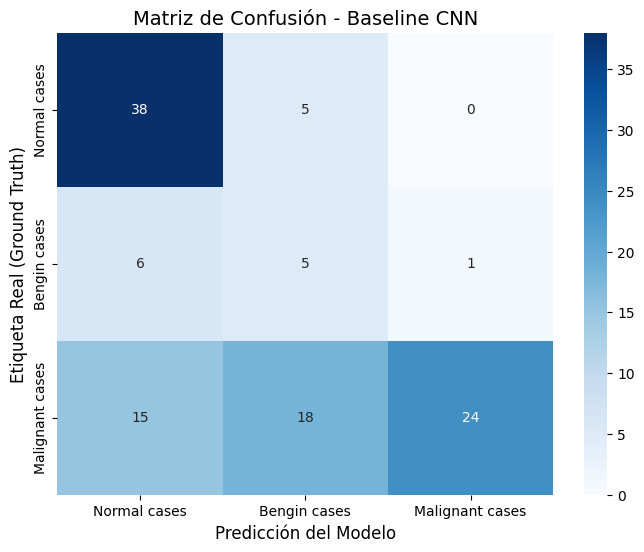

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Asegurarnos de que el generador de test empiece desde el principio
print("Evaluando en el conjunto de TEST...")
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(OUTPUT_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=class_names, # Usamos las 3 clases correctas
    class_mode='categorical',
    shuffle=False # CRÍTICO: No mezclar para que coincidan las etiquetas
)

# 2. Hacer las predicciones
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1) # Nos quedamos con la clase de mayor probabilidad
y_true = test_generator.classes # Las etiquetas reales

# 3. Reporte de Clasificación (Métricas clínicas)
print("\n" + "="*40)
print("        CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Generar y pintar la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Baseline CNN', fontsize=14)
plt.ylabel('Etiqueta Real (Ground Truth)', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.show()

### 5. Discusión de Resultados: Modelo Baseline CNN

Tras evaluar la red neuronal convolucional (CNN) diseñada para este proyecto, el modelo presenta una precisión global (*accuracy*) del **60%**. Este resultado, analizado en conjunto con pruebas previas, permite extraer conclusiones fundamentales sobre la robustez del sistema:

#### 1. Alta Especificidad en Malignidad vs. Bajo Recall
Un hallazgo clave es la **Precision del 96%** en la clase `Malignant cases`. Este valor indica que el modelo es extremadamente fiable cuando identifica un tumor como maligno (pocos falsos positivos). Sin embargo, esto se traduce en un **Recall del 42%**, lo que implica un comportamiento "conservador": la red solo etiqueta como cáncer los casos con características muy evidentes, dejando sin detectar una parte significativa de la clase mayoritaria.

#### 2. Sesgo de Detección hacia la Normalidad
El modelo muestra una gran capacidad para identificar tejido sano, con un **Recall del 88%** en `Normal cases`. No obstante, la matriz de confusión revela que esta tendencia a la "normalidad" provoca que el modelo clasifique erróneamente nódulos patológicos como sanos, un riesgo clínico que debe ser mitigado en futuras iteraciones.

#### 3. El Desafío de la Clase Benigna
La clase `Bengin cases` representa el mayor reto. Con un **F1-Score de 0.25**, el modelo presenta dificultades para diferenciar lesiones benignas de las normales o malignas. La baja precisión (18%) confirma que una arquitectura sencilla no logra captar las diferencias morfológicas sutiles (bordes, texturas) que caracterizan a los tumores no cancerosos.

#### 4. Análisis de Inestabilidad y Generalización
Es imperativo destacar que, tras realizar varias ejecuciones del entrenamiento, se ha observado una **alta variabilidad en las métricas**. El hecho de obtener resultados distintos (oscilando entre el 57% y el 60% de accuracy con cambios drásticos en el recall por clase) es una señal clara de que la red sufre de **inestabilidad en la convergencia**.

Esta fluctuación indica que el modelo "generaliza mal"; al ser una arquitectura simple entrenada desde cero con un dataset limitado, es extremadamente sensible a la inicialización aleatoria de los pesos y a las variaciones del *Data Augmentation*. La red no ha logrado encontrar un "mínimo global" estable, sino que se detiene en diferentes soluciones subóptimas en cada intento.

### Conclusión y Siguientes Pasos
Este Baseline confirma que el preprocesamiento es funcional, pero evidencia que el "cerebro" del modelo es insuficiente y poco robusto. La inestabilidad observada justifica plenamente la transición hacia **Transfer Learning** en el cuaderno `03_transfer_learning.ipynb`. Al emplear arquitecturas como **ResNet50**, partiremos de un conocimiento previo (pesos pre-entrenados) que aportará la estabilidad y la capacidad de extracción de características profundas que este modelo base no puede alcanzar.